In [46]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
# df_raw = pd.read_csv('data/EJI_2024_United_States.csv')
df_raw = pd.read_csv("data/EJI_2024_United_States_CSV/EJI_2024_United_States.csv")
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

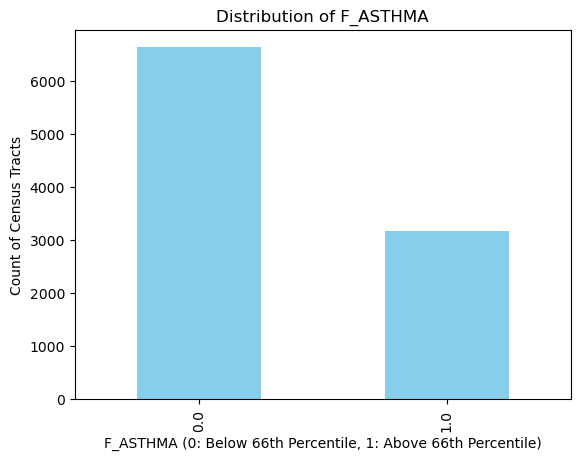

In [48]:
# Create bar chart of F_ASTHMA distribution
counts = df['F_ASTHMA'].value_counts().sort_index() # Count occurrences of 0 and 1 and then sort by index to ensure 0 before 1
counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of F_ASTHMA')
plt.xlabel('F_ASTHMA (0: Below 66th Percentile, 1: Above 66th Percentile)')
plt.ylabel('Count of Census Tracts')
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 


The response variable `F_ASTHMA` is imbalanced. More than 6,000 tracts are labeled as `0` and about 3,000 tracts are labeled `1`; the majority class (< 66th percentile) is roughly twice as large as the minority class (> 66th percentile). A classifier could return a high accuracy by predicting a census track as `0` (< 66th percentile) too often, even if it misses several high-risk tracts. As a result, accuracy can be misleading; metric like precision and recall (along with a confusion matrix) can be used to understand how well the model identifies the minority class.

<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [53]:
df_model = df[["F_ASTHMA", "EPL_POV200", "EPL_UNEMP", "EPL_MINRTY"]].dropna()
X = df_model[["EPL_POV200", "EPL_UNEMP", "EPL_MINRTY"]] 
y = df_model["F_ASTHMA"].astype(int) # Ensure target is binary int for classification

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')


Training set : 6,813 tracts
Test set     : 2,920 tracts


In [54]:
grader.check("q3")

q3 results:
    q3 - 1 result:
        ✅ Test case passed

    q3 - 2 result:
        ✅ Test case passed

    q3 - 3 result:
        ❌ Test case failed
        Trying:
            ((X_train >= 0) & (X_train <= 1)).all()
        Expecting:
            True
        **********************************************************************
        Line 1, in q3 2
        Failed example:
            ((X_train >= 0) & (X_train <= 1)).all()
        Expected:
            True
        Got:
            EPL_POV200    True
            EPL_UNEMP     True
            EPL_MINRTY    True
            dtype: bool

    q3 - 4 result:
        ✅ Test case passed

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [55]:
knn3 = KNeighborsClassifier(n_neighbors=3)

# Fit KNN model on training data
knn3.fit(X_train, y_train)

# Predict on test set
y_pred_knn3 = knn3.predict(X_test)

# Look at accuracy metric
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


In [56]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

In [ ]:
k_values       = ...
cv_mean_scores = ...



optimal_k     = ...
best_cv_score = ...

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 4))  
ax.plot(k_values, cv_mean_scores, marker='o', color='steelblue', linewidth=1.8, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='firebrick', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=13) 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [ ]:
grader.check("q5")

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [ ]:

knn_optimal_accuracy = ...

print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')

In [ ]:
grader.check("q7")

<!-- BEGIN QUESTION -->


> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [ ]:
lr = ...

y_pred_lr   = ...
lr_accuracy = ...
lr_accuracy

In [ ]:
grader.check("q9")

<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

In [ ]:
cm_lr = ...



In [ ]:
grader.check("q11")

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [ ]:
accuracy_lr  = ...
precision_lr = ...
recall_lr    = ...
f1_lr        = ...

print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

In [ ]:
grader.check("q13")

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

In [ ]:
cm_knn = ...


precision_knn = ...
recall_knn    = ...
f1_knn        = ...

print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

In [ ]:
grader.check("q15")

<!-- BEGIN QUESTION -->

> **Q6:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why? 

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

In [ ]:
y_proba_lr = ...
fpr, tpr, thresholds = ...
roc_auc = ...


print(f'Logistic Regression AUC: {roc_auc:.4f}')

In [ ]:
grader.check("q17")

<!-- BEGIN QUESTION -->

> **Q7:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

_Type your answer here, replacing this text._

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [ ]:
grader.check_all()